<a href="https://colab.research.google.com/github/Sanika-Nayse/DemoProject/blob/main/FakeNewsDetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [96]:
import pandas as pd
import glob
import os
import warnings
warnings.filterwarnings("ignore")

In [97]:
#Mount Google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [98]:
train_path = r"/content/drive/MyDrive/English (1)/Train"
test_path = r"/content/drive/MyDrive/English (1)/Test"

In [99]:
train_all_files = glob.glob(os.path.join(train_path, "*.txt"))
train_all_files

['/content/drive/MyDrive/English (1)/Train/train_English_Data_Technology.txt',
 '/content/drive/MyDrive/English (1)/Train/train_English_Data_Complete_FakeNews.txt',
 '/content/drive/MyDrive/English (1)/Train/train_English_Data_Entertainment.txt',
 '/content/drive/MyDrive/English (1)/Train/train_English_Data_Education.txt',
 '/content/drive/MyDrive/English (1)/Train/train_English_Data_Business.txt',
 '/content/drive/MyDrive/English (1)/Train/train_English_Data_Celebrity_Full.txt',
 '/content/drive/MyDrive/English (1)/Train/train_English_Data_Politics.txt',
 '/content/drive/MyDrive/English (1)/Train/train_English_Data_Sports.txt']

In [100]:
test_all_files = glob.glob(os.path.join(test_path, "*.txt"))
test_all_files

['/content/drive/MyDrive/English (1)/Test/test_English_Data_Business.txt',
 '/content/drive/MyDrive/English (1)/Test/test_English_Data_Celebrity_Full.txt',
 '/content/drive/MyDrive/English (1)/Test/test_English_Data_Education.txt',
 '/content/drive/MyDrive/English (1)/Test/test_English_Data_Entertainment.txt',
 '/content/drive/MyDrive/English (1)/Test/test_English_Data_Complete_FakeNews.txt',
 '/content/drive/MyDrive/English (1)/Test/test_English_Data_Sports.txt',
 '/content/drive/MyDrive/English (1)/Test/test_English_Data_Politics.txt',
 '/content/drive/MyDrive/English (1)/Test/test_English_Data_Technology.txt']

In [101]:
dfs = []

for file in train_all_files:

    df = pd.read_csv(
        file,
        sep="\t",
        encoding="utf-8"
    )

    dfs.append(df)

train_df = pd.concat(
    dfs,
    ignore_index=True
)

In [102]:
dfs = []

for file in test_all_files:

    df = pd.read_csv(
        file,
        sep="\t",
        encoding="utf-8"
    )

    dfs.append(df)

test_df = pd.concat(
    dfs,
    ignore_index=True
)

In [103]:
train_df.head()

,Domain,Topic,News,Label
0,Technology,"No new threat led to airline laptop limits, of...",U.S. and British officials said Tuesday the de...,Legit
1,Technology,Amazon Prime Air drone completes its first US ...,Amazon Prime Air said Thursday it shipped its ...,Legit
2,Technology,Yahoo Denies Data Breach from 500M Accounts,While many news outlets are reporting the stat...,Fake
3,Technology,"Netflix is testing a 'Skip Intro' button, and ...",No more watching the same minute-long intro so...,Legit
4,Technology,"AT&T pulls ads from YouTube, other Google sites",AT&T doesn't want its name showing up next to ...,Legit


In [104]:
test_df.head()

,Domain,Topic,News,Label
0,Business,California Surprisingly Lenient on Auto Emissi...,"Setting Up Face-Off With Trump ""California's c...",Fake
1,Business,"Elon Musk, the brains behind Tesla, SpaceX, an...",Colleges and universities are working with Pre...,Fake
2,Business,Energy Minister Alexander Novak sited that the...,"When the new trailer for ""Justice League"" appe...",Fake
3,Business,Amazon to sell Middle East online retailer Souq,"""Amazon has made its first big sale into the M...",Fake
4,Business,Wells Fargo profits spike despite legal costs,"""Despite the looming court costs of its recent...",Fake


In [105]:
print(train_df.shape)
print(test_df.shape)

(1188, 4)
(772, 4)


In [106]:
train_df.to_csv(
    "english_train_combined.csv",
    index=False
)

In [107]:
test_df.to_csv(
    "english_test_combined.csv",
    index=False
)

In [108]:
final_df = pd.concat(
    [train_df,test_df],
    ignore_index=True
)

In [109]:
final_df["Label"] = final_df["Label"].map({
    "Fake":0,
    "Legit":1
})

In [110]:
final_df.to_csv(
    "fake_news_english.csv",
    index=False
)

In [111]:
final_df = final_df[
    ["News","Label","Domain"]
]

In [112]:
final_df.columns = [
    "text",
    "label",
    "domain"
]

In [113]:
final_df.shape

(1960, 3)

## Import Libraries

In [114]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re
import string

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from xgboost import XGBClassifier


In [115]:
pip install xgboost shap

# Dataset Overview (EDA)

In [116]:
print(final_df.shape)

(1960, 3)


In [117]:
final_df.head()

,text,label,domain
0,U.S. and British officials said Tuesday the de...,1,Technology
1,Amazon Prime Air said Thursday it shipped its ...,1,Technology
2,While many news outlets are reporting the stat...,0,Technology
3,No more watching the same minute-long intro so...,1,Technology
4,AT&T doesn't want its name showing up next to ...,1,Technology


Handle Missing values

In [118]:
final_df.isnull().sum()

,0
text,2
label,0
domain,0


In [119]:
final_df.dropna(inplace=True)

Label Distribution


In [120]:
final_df["label"].value_counts()

,count
label,
1,980
0,978


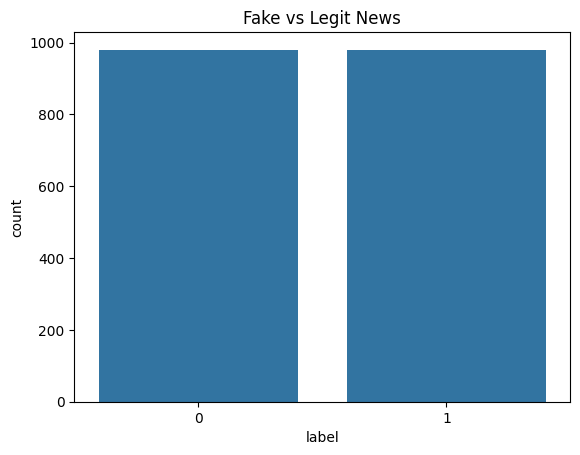

In [121]:
sns.countplot(
    x=final_df["label"]
)

plt.title("Fake vs Legit News")
plt.show()

Domain Distribution

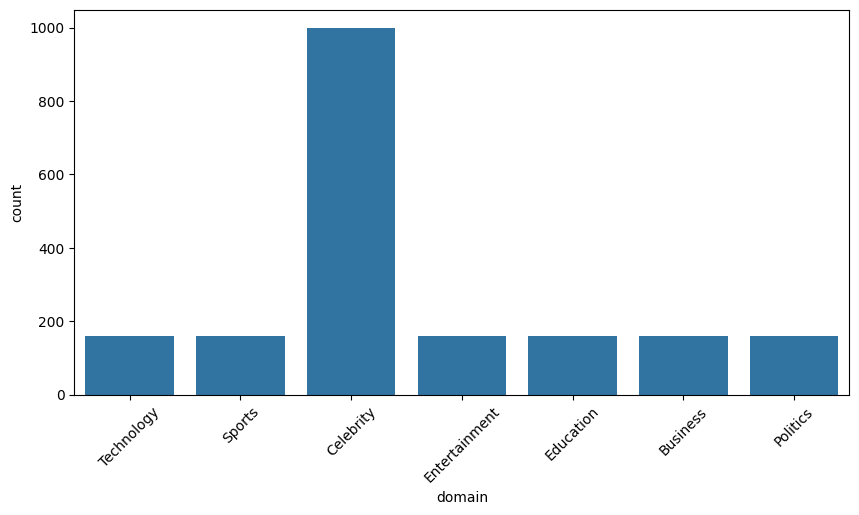

In [122]:
plt.figure(figsize=(10,5))

sns.countplot(
    x=final_df["domain"]
)

plt.xticks(rotation=45)

plt.show()

# Data Cleaning

In [123]:
def clean_text(text):

    text = str(text).lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"\d+", "", text)

    text = re.sub(
        r"[^\w\s]",
        "",
        text
    )

    text = re.sub(
        r"\s+",
        " ",
        text
    )

    return text.strip()

In [124]:
final_df["clean_text"] = final_df["text"].apply(clean_text)

In [125]:
final_df[
    ["text","clean_text"]
].head()

,text,clean_text
0,U.S. and British officials said Tuesday the de...,us and british officials said tuesday the deci...
1,Amazon Prime Air said Thursday it shipped its ...,amazon prime air said thursday it shipped its ...
2,While many news outlets are reporting the stat...,while many news outlets are reporting the stat...
3,No more watching the same minute-long intro so...,no more watching the same minutelong intro son...
4,AT&T doesn't want its name showing up next to ...,att doesnt want its name showing up next to vi...


In [126]:
final_df["label"]

,label
0,1
1,1
2,0
3,1
4,1
...,...
1955,1
1956,1
1957,1
1958,0


In [127]:
final_df["label"].value_counts()

,count
label,
1,980
0,978


In [128]:
X = final_df["clean_text"]

y = final_df["label"]

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

#Feature Engineering

In [129]:
tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=10000
)

X_train_tfidf = tfidf.fit_transform(
    X_train
)

X_test_tfidf = tfidf.transform(
    X_test
)

# Model Development

Naive Bayes Model

In [130]:
nb = MultinomialNB()

nb.fit(
    X_train_tfidf,
    y_train
)

MultinomialNB()

In [131]:
nb_pred = nb.predict(
    X_test_tfidf
)

In [132]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

nb_pred = nb.predict(X_test_tfidf)

print("Accuracy :", accuracy_score(y_test, nb_pred))
print("Precision:", precision_score(y_test, nb_pred))
print("Recall   :", recall_score(y_test, nb_pred))
print("F1 Score :", f1_score(y_test, nb_pred))

print("\nClassification Report")
print(classification_report(y_test, nb_pred))

Accuracy : 0.7933673469387755
Precision: 0.8108108108108109
Recall   : 0.7653061224489796
F1 Score : 0.7874015748031497

Classification Report
              precision    recall  f1-score   support

           0       0.78      0.82      0.80       196
           1       0.81      0.77      0.79       196

    accuracy                           0.79       392
   macro avg       0.79      0.79      0.79       392
weighted avg       0.79      0.79      0.79       392



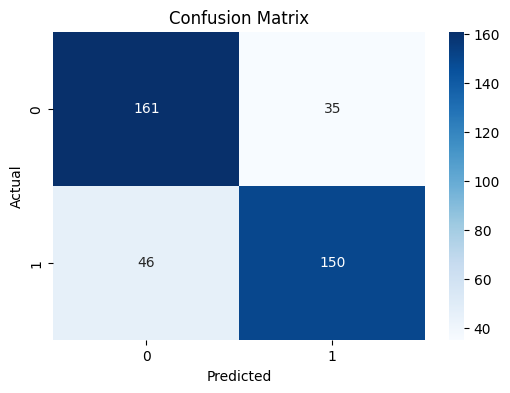

In [133]:
cm = confusion_matrix(
    y_test,
    nb_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

XGBoost Model

In [134]:
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)

In [135]:
xgb.fit(
    X_train_tfidf,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

In [136]:
xgb_pred = xgb.predict(
    X_test_tfidf
)

In [137]:
xgb_pred = xgb.predict(X_test_tfidf)

print("Accuracy :", accuracy_score(y_test, xgb_pred))
print("Precision:", precision_score(y_test, xgb_pred))
print("Recall   :", recall_score(y_test, xgb_pred))
print("F1 Score :", f1_score(y_test, xgb_pred))

print("\nClassification Report")
print(classification_report(y_test, xgb_pred))

Accuracy : 0.8647959183673469
Precision: 0.8177777777777778
Recall   : 0.9387755102040817
F1 Score : 0.8741092636579573

Classification Report
              precision    recall  f1-score   support

           0       0.93      0.79      0.85       196
           1       0.82      0.94      0.87       196

    accuracy                           0.86       392
   macro avg       0.87      0.86      0.86       392
weighted avg       0.87      0.86      0.86       392



In [138]:
xgb_probs = xgb.predict_proba(X_test_tfidf)[:,1]

roc_score = roc_auc_score(
    y_test,
    xgb_probs
)

print("ROC AUC Score:", roc_score)

ROC AUC Score: 0.9324890670553937


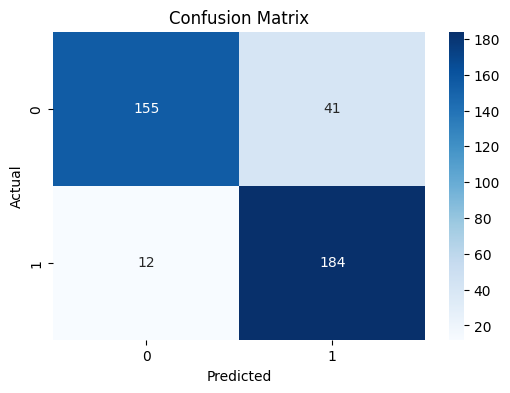

In [139]:
cm = confusion_matrix(
    y_test,
    xgb_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

# Model Evaluation

In [140]:
results = pd.DataFrame({
    "Model":["Naive Bayes","XGBoost"],
    "Accuracy":[
        accuracy_score(y_test, nb_pred),
        accuracy_score(y_test, xgb_pred)
    ],
    "Precision":[
        precision_score(y_test, nb_pred),
        precision_score(y_test, xgb_pred)
    ],
    "Recall":[
        recall_score(y_test, nb_pred),
        recall_score(y_test, xgb_pred)
    ],
    "F1 Score":[
        f1_score(y_test, nb_pred),
        f1_score(y_test, xgb_pred)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Naive Bayes,0.793367,0.810811,0.765306,0.787402
1,XGBoost,0.864796,0.817778,0.938776,0.874109


# SHAP Explainability

In [141]:
import shap

In [143]:
import shap

X_train_sample = X_train_tfidf[:100].toarray()

explainer = shap.TreeExplainer(xgb)

shap_values = explainer.shap_values(X_train_sample)

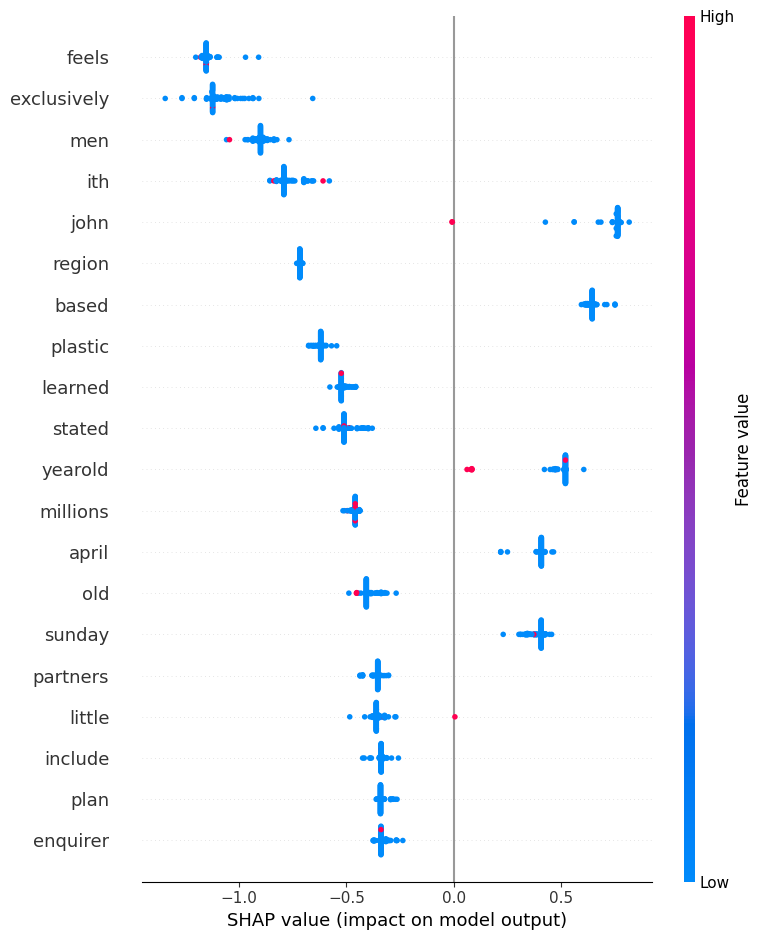

In [144]:
feature_names = tfidf.get_feature_names_out()

shap.summary_plot(
    shap_values,
    X_train_sample,
    feature_names=feature_names
)

Plot Top 20 Words

In [146]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": tfidf.get_feature_names_out(),
    "Importance": xgb.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(20)

,Feature,Importance
2690,exclusively,0.012442
7296,stated,0.010252
105,administration,0.009504
1560,commented,0.007540
4933,millions,0.007493
7859,took,0.007380
6856,service,0.007168
283,america,0.006809
2271,donald,0.006802
7995,trump,0.006733


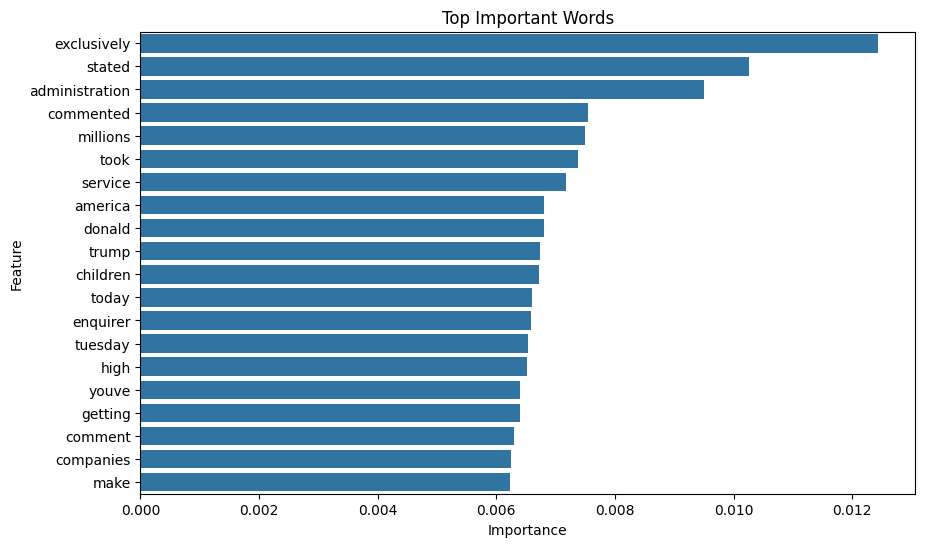

In [147]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(20),
    x="Importance",
    y="Feature"
)

plt.title("Top Important Words")
plt.show()

Confidence Score Predictor

In [148]:
def predict_news(news):

    cleaned = clean_text(news)

    vector = tfidf.transform(
        [cleaned]
    )

    prediction = xgb.predict(
        vector
    )[0]

    probability = xgb.predict_proba(
        vector
    )[0]

    confidence = np.max(
        probability
    ) * 100

    label = (
        "FAKE"
        if prediction == 1
        else "LEGIT"
    )

    return label, confidence

# Interactive Input

In [150]:
while True:

    news = input(
        "\nEnter News: "
    )

    label, confidence = predict_news(
        news
    )

    print(
        f"\nPrediction : {label}"
    )

    print(
        f"Confidence : {confidence:.2f}%"
    )

    again = input(
        "\nCheck another? (y/n): "
    )

    if again.lower() != "y":
        break


Enter News: Trump calls Democrats 'losers' after GOP health bill failure	President Donald Trump spoke out Friday afternoon after Republicans pulled the Obamacare overhaul he had endorsed, criticizing Democratic opposition to the bill and passing off the responsibility for its failure.	

Prediction : FAKE
Confidence : 90.29%

Check another? (y/n): y

Enter News: Trump targets tech's H-1B visa hiring tool	SAN FRANCISCO - President Trump's relationship with Silicon Valley has always been volatile at best, but it seems things soon may get even more contentious

Prediction : LEGIT
Confidence : 51.41%

Check another? (y/n): n


# Word Cloud

In [151]:
from wordcloud import WordCloud

In [152]:
fake_text = " ".join(
    final_df[
        final_df["label"]==1
    ]["clean_text"]
)

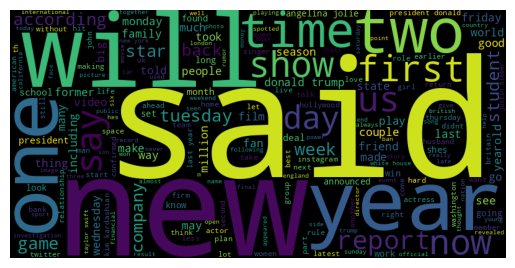

In [153]:
wc = WordCloud(
    width=800,
    height=400
)

plt.imshow(
    wc.generate(fake_text)
)

plt.axis("off")
plt.show()